## K Nearest Neighbors

### Tipos de distancia

* Euclidiana: 
    * $\sqrt{(a_1 - b_1)^2 + ... + (a_n - b_n)^2}$
    * `.euclidean()`
* Manhattan: similar a como caminarías por una ciudad  
    * $|a_1 - b_1| + ... + |a_n - b_n|$
    * `.cityblock()`
* Hamming: solo le importa si las dimensiones son iguales, útil para cosas como spell checkers y record linkage 
    * ejemplo: distancia entre `there` y `thete` es 1 (estas dos palabras solo difieren por la letra r/t)
    * `.hamming()`: sumar las diferencias y las divide por el número de dimensiones 

In [1]:
# Ejemplo: 
from scipy.spatial import distance
print(distance.euclidean([1,2],[4,0]))
print(distance.cityblock([1,2],[4,0]))
print(distance.hamming([5,4,9],[1,7,9]))

3.605551275463989
5
0.6666666666666666


* Recuerdas que hace knn?
* Cuales eran los pasos?

1. Seleccionamos k 
1. Normalizamos los datos y calculamos las distancias entre todos los puntos y el nuevo 
1. Encontramos los k vecinos más cercanos 
1. Clasificamos/Predecimos el nuevo punto usando esos vecinos 

Vamos a hacer un ejemplo manual: 

* vamos a usar $k = 3$ (PASO 1!)
* tenemos las siguiente información sobre casas:

| MedIncome | HouseAge | AvRooms | MedHouseValue|
|-----|-----|-----|-----|
|8.3252 |	41.0 	| 6.984127 |4.526|
|8.3014 |	21.0 	| 6.238137 |3.585|
|7.2574 |	52.0 	| 8.288136 |3.521|
|5.6431 |	52.0 	| 5.817352 |3.413|
|3.8462 |	52.0 	| 6.281853  |3.422|

* queremos predecir el valor de una 'nueva casa' con las siguientes características: 

| MedIncome | HouseAge | AvRooms | MedHouseValue|
|-----|-----|-----|-----|
|3.6591| 52 | 4.931907 | 2.992|
  
Pasamos esto a un mini data frame

In [2]:
import pandas as pd
import numpy as np
import math
train = pd.DataFrame({'MedIncome':[8.3252, 8.3014, 7.2574, 5.6431, 3.8462],
         'HouseAge':[41.0, 21.0, 52.0, 52.0, 52.0],
         'AvRooms':[6.984127, 6.238137, 8.288136, 5.817352, 6.281853],
         'MedHouseVal':[4.526, 3.585, 3.521, 3.413, 3.422]})
test = pd.DataFrame({'MedIncome': [3.6591],
                     'HouseAge': [52],
                     'AvRooms': [4.931907]})   

In [3]:
## Escalamos los datos (PASO 2!) 
## ¿Por qué es importante este paso para KNN?

from sklearn.preprocessing import MinMaxScaler

X_train = train[['MedIncome', 'HouseAge', 'AvRooms']]
y_train = train[['MedHouseVal']]
scaler = MinMaxScaler()
scaler.fit(X_train)
data = scaler.transform(X_train)
data

array([[1.        , 0.64516129, 0.47222865],
       [0.99468631, 0.        , 0.17030424],
       [0.76159857, 1.        , 1.        ],
       [0.4011833 , 1.        , 0.        ],
       [0.        , 1.        , 0.18799741]])

### ¿Qué esta haciendo el `MinMaxScaler()`?

* Vuelve la feature más pequeña cero y la más grande 1
* Escala los valores entre cero y uno sin cambiar la forma de la distribución original
* $x_{scaled}  = \frac{x - min(X)}{max(X) - min(X)}$

### Hacemos lo mismo con el test set:

OJO: `sklearn` usa solo los datos del entrenamiento para escalar, eso evita leaking sin que lo tengamos que controlar explicitamente

In [4]:
X_test = test
test_scaled = scaler.transform(X_test)
test_scaled

array([[-0.04177272,  1.        , -0.35836601]])

In [5]:
data_df = pd.DataFrame(data, columns=['MedIncome', 
'HouseAge', 'AvRooms'])
data_df['MedHouseVal'] = [4.526, 3.585, 
3.521, 3.413, 3.422]
data_df

,MedIncome,HouseAge,AvRooms,MedHouseVal
0,1.000000,0.645161,0.472229,4.526
1,0.994686,0.000000,0.170304,3.585
2,0.761599,1.000000,1.000000,3.521
3,0.401183,1.000000,0.000000,3.413
4,0.000000,1.000000,0.187997,3.422


In [6]:
## Sacar distancias entre todos los puntos y el nuevo (PASO 2!)

d_1 = math.sqrt(pow((1 - (-0.04177272)), 2) + pow(( 0.645161-1),2) + pow((0.472229- (-0.35836601)),2))
d_2 = math.sqrt(pow((0.994686 - (-0.04177272)), 2) + pow((0-1),2) + pow((0.170304- (-0.35836601)),2))
d_3 = math.sqrt(pow((0.761599 - (-0.04177272)), 2) + pow((1-1),2) + pow((1 - (-0.35836601)),2))
d_4 = math.sqrt(pow((0.401183 - (-0.04177272)), 2) + pow((1-1),2) + pow((0 - (-0.35836601)),2))
d_5 = math.sqrt(pow((0 - (-0.04177272)), 2) + pow((1-1),2) + pow((0.187997- (-0.35836601)),2))
data_df['distance'] = [d_1, d_2, d_3, d_4, d_5]
data_df 

,MedIncome,HouseAge,AvRooms,MedHouseVal,distance
0,1.000000,0.645161,0.472229,4.526,1.378800
1,0.994686,0.000000,0.170304,3.585,1.534190
2,0.761599,1.000000,1.000000,3.521,1.578152
3,0.401183,1.000000,0.000000,3.413,0.569768
4,0.000000,1.000000,0.187997,3.422,0.547958


In [7]:
## Sacar los k vecinos más cercanos (PASO 3!)
data_df.sort_values(by="distance", ascending=True)

,MedIncome,HouseAge,AvRooms,MedHouseVal,distance
4,0.000000,1.000000,0.187997,3.422,0.547958
3,0.401183,1.000000,0.000000,3.413,0.569768
0,1.000000,0.645161,0.472229,4.526,1.378800
1,0.994686,0.000000,0.170304,3.585,1.534190
2,0.761599,1.000000,1.000000,3.521,1.578152


### Usamos los k vecinos para predecir (PASO 4!)
* Es una regresión entonces nuestra predicción va a ser el promedio de los vecinos

In [8]:
pred = data_df.sort_values(by="distance", ascending=True)[:3].MedHouseVal.mean()

#Error en nuestra prediccion:
abs(pred - 2.992)

0.7950000000000004

### Parametros del modelo
* ¿Cuántos vecinos? $k$
* ¿Qué medida de distancia usar? 
   * depende del problema en especifico
   
Ahora vamos a usar la base completa usando `sklearn`   

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame=True)

housing = california_housing.frame
housing.head()
housing.shape
housing.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

<Axes: ylabel='Frequency'>

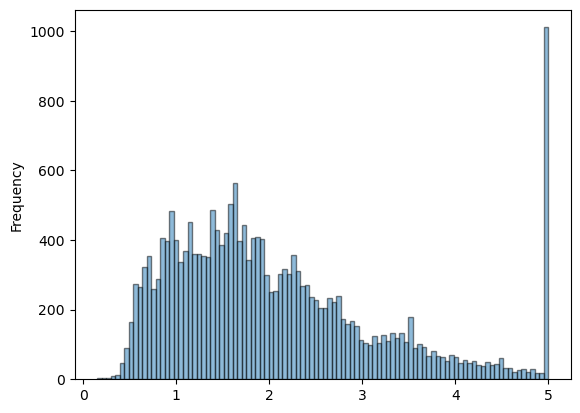

In [11]:
# Mini analisis exploratorio:
housing.describe().T

# distribución del precio de las casa
housing.MedHouseVal.plot.hist(bins = 100, 
                  alpha=0.5, histtype='bar', ec='black')

In [12]:
# Separamos en features y target:
X = housing.drop(['MedHouseVal'], axis=1)
y = housing.MedHouseVal
(X.shape, y.shape)

# dividimos en train y test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1234)

Escalamos todas las variables usando `StandardScaler`

standar scaler: $z = \frac{x - u}{s}$ donde la $u$ es la media y $s$ la desviación estándar 

In [13]:
scaler = StandardScaler()
scaler.fit(X_train, y_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ¿Cómo se ve la base escalada?
col_names= ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
scaled_df = pd.DataFrame(X_train, columns=col_names)
scaled_df.describe().T

# Aplicamos KNN

knn_model = {}
for k in range(1, 40):
  knn = KNeighborsRegressor(n_neighbors = k, p = 2, n_jobs = -1)
  # aca p es la distancia (2 == euclidiana) y n_jobs es 
  # cuantos procesadores podemos usar en parallelo (-1) es todos 
  knn.fit(X_train_scaled, y_train)
  start = time.time()
  predicted_prices = knn.predict(X_test_scaled)
  knn_model['neighbors_' + str(k)] = {'predicted_prices': predicted_prices}


## Métricas de desempeño
Para problemas de regresión podemos usar:

* MAE (Mean Absolute Error) 
    * $mae = \frac{1}{n}\sum_{i=1}^n|Actual - Predicted|$
    * noción de error global entre más cerca de cero mejor
* MSE (Mean Squared Error)
    * $mse = \sum_{i=1}^n (Actual - Predicted)^2$
    * hace errores grandes aún más grandes 
    * difícil de interpretar 
* RMSE (Root Mean Squared Error)
    * $rsme = \sqrt{\sum_{i=1}^n (Actual - Predicted)^2}$
    * escala la mse 
    * nos muestra cuanto pueden variar nuestros datos 
* $R^2$ coefficient of determination 
    * $R^2 = \frac{\sum(Actual - Predicted)^2}{\sum(Actual - ActualMean)^2}$
    * cuanto de la varianza original puede explicar el modelo

In [14]:
## Usemos mae para este ejemplo: 
from sklearn.metrics import mean_absolute_error
error = []
for k in knn_model.keys():
    mae = mean_absolute_error(y_test, knn_model[k]['predicted_prices'])
    error.append(mae)

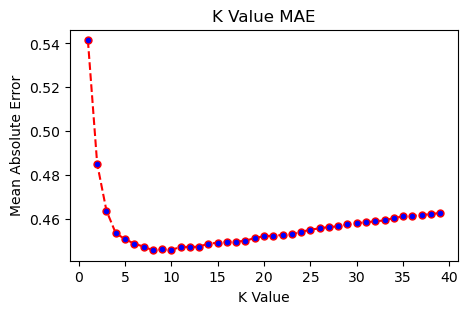

In [15]:
# ¿Cómo escogemos la k?

fig, ax = plt.subplots(figsize=(5, 3))
ax = plt.plot(range(1, 40), error, color='red', 
         linestyle = 'dashed', marker = 'o',
         markerfacecolor = 'blue', markersize = 5)
         
plt.title('K Value MAE')
plt.xlabel('K Value')
plt.ylabel('Mean Absolute Error')
plt.show()

In [17]:
## ¿Cómo guardo mi modelo?
import pickle
knn_opt = KNeighborsRegressor(n_neighbors = 6, p = 2, n_jobs = -1)
knn_opt.fit(X_train_scaled, y_train)
filename = 'knn_opt.pkl'
#pickle.dump(knn_opt, open(filename, 'wb'))

## Arboles de decisión

In [19]:
## Cargar datos
diabetes = pd.read_csv('../data/diabetes.csv')
diabetes.shape
diabetes.rename(columns={col: col.lower() for col in diabetes.columns.values}, inplace=True)
diabetes.columns

Index(['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin',
       'bmi', 'diabetespedigreefunction', 'age', 'outcome'],
      dtype='object')

In [20]:
# mini analisis exploratorio
diabetes.describe().T
diabetes.outcome.value_counts()

0    500
1    268
Name: outcome, dtype: int64

In [21]:
# Dividimos los datos en features y label/target
X = diabetes.drop(['outcome'], axis=1)
y = diabetes.outcome
(X.shape, y .shape)

X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.3, random_state = 1234)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(537, 8) (537,)
(231, 8) (231,)


### Árbol de decisión: algorítmo

1. Obtenemos la entropía (medida de información) de la variable objetivo 
1. Obtenemos la entropía de la variable a clasificar con respecto a una variable predicadora 
1. Obtenemos la ganancia de la variable seleccionada en el paso anterior
1. Repetimos dos y tres para todas las variables predicadoras
1. Seleccionamos la variable con mayor ganancia de información y esta sera nuestro nodo raíz 
1. Repetimos para todas las observaciones y variables cuya entropía es mayor a cero hasta que sea cero o que no haya más observaciones por dividir 


### Criterio de selección de variables 
* Entropía/ Ganancia d información:
    * mide el desorden de los nodos
    * entropía alta quiere decir que los datos son heterogéneos 
    * $Ent(T) = -\sum_{i = 1}^n p_ilog_2p_i$
* Gini/Impureza: 
    * mide la probabilidad de que clasifiques mal una instancia 
    * entre más pequeño la probabilidad de que clasifiques mal disminuye 
    * entre 0 (puro) y $0.5$ (as good as random) 
    * $Gini(T) = 1 - \sum_{i=1}^k p_i^2$
    
Recuerda: queremos que los nodos terminales sean lo más homogéneos/puros posibles    

In [22]:
## Declaramos nuestro arbol

from sklearn.tree import DecisionTreeClassifier, plot_tree

# por default el criterio es gini y aca estamos escogiendo
# cuantos elementos por hoja 
dt = DecisionTreeClassifier(criterion = "gini", min_samples_leaf = 5, random_state = 1234)
dt.fit(X_train, y_train)

DecisionTreeClassifier(min_samples_leaf=5, random_state=1234)

In [23]:
## ¿Qué variables escogio el árbol?

feature_importances_df = pd.DataFrame({'feature': X.columns.values, 
                                       'importance': dt.feature_importances_})
feature_importances_df.sort_values(by="importance", ascending=False) 

,feature,importance
1,glucose,0.515329
5,bmi,0.125538
7,age,0.116646
6,diabetespedigreefunction,0.071970
2,bloodpressure,0.048074
0,pregnancies,0.047151
3,skinthickness,0.046145
4,insulin,0.029147


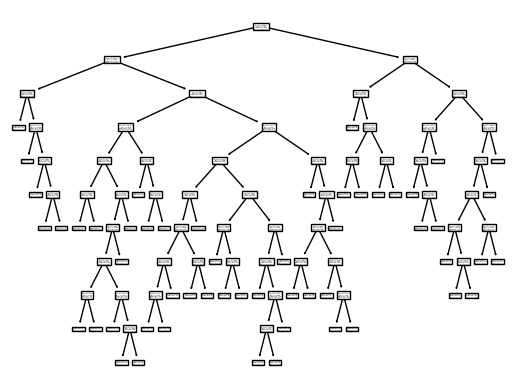

In [24]:
## ¿Cómo se ve este arbol?
plt.clf() 
plot_tree(dt)
plt.show()

In [25]:
## Otra manera de ver el árbol 
from sklearn.tree import export_text
decisions = export_text(dt, feature_names=X.columns.to_list())
print(decisions)

|--- glucose <= 143.50
|   |--- bmi <= 27.55
|   |   |--- glucose <= 106.50
|   |   |   |--- class: 0
|   |   |--- glucose >  106.50
|   |   |   |--- bloodpressure <= 52.00
|   |   |   |   |--- class: 0
|   |   |   |--- bloodpressure >  52.00
|   |   |   |   |--- glucose <= 108.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- glucose >  108.50
|   |   |   |   |   |--- skinthickness <= 28.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- skinthickness >  28.50
|   |   |   |   |   |   |--- class: 0
|   |--- bmi >  27.55
|   |   |--- age <= 28.50
|   |   |   |--- glucose <= 127.50
|   |   |   |   |--- skinthickness <= 5.00
|   |   |   |   |   |--- glucose <= 114.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- glucose >  114.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- skinthickness >  5.00
|   |   |   |   |   |--- diabetespedigreefunction <= 0.90
|   |   |   |   |   |   |--- insulin <= 89.00
|   |   |   |   |   |   |   |--- pregn

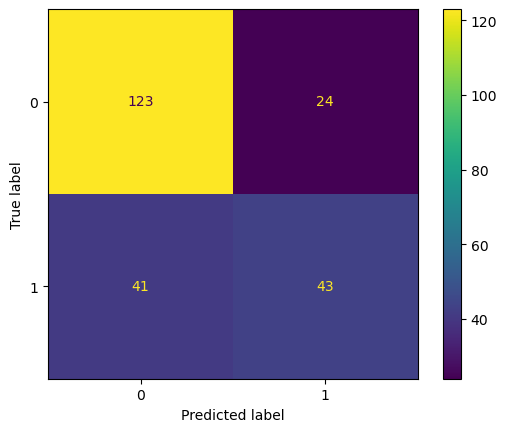

In [26]:
## ¿Cómo lo hizo el modelo?

# Etiquetas 
predictions_labels = dt.predict(X_test)
# Probabilidad de pertenencia 
predictions_scores = dt.predict_proba(X_test)
predictions_scores[:10]
dt.classes_


## Accurancy y 
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions_labels)

## Matriz de Confusion 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predictions_labels, labels = dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = dt.classes_)
disp.plot()
plt.show()

### Evaluación del modelo

* ¿Cómo estamos decidiendo el punto de corte para la etiqueta positiva vs negativa?
* Cambia en algo nuestra predicción si cambiamos este punto de corte?

### ROC curve 
* ROC curve (receiver operating curve): muestra que tan bien lo hace el modelo en diferentes puntos de corte para la clasificación. Grafica dos cosas:
    * TPR (True Positive Rate): $TPR = \frac{TP}{TP + FN}$  Te parece conocido? 
    * FPR (False Positive Rate): $FPR = \frac{FP}{FP + TP}$
    
### AUC     
* AUC (area under the ROC curve): el area/la integral de toda la ROC curve. Medida agregada de desempeño a lo largo de todos los posibles cortes de clasificación.
    * es invariante a la escala: mide que tan bien rankeadas están las predicciones  
    * es invariante al corte: mide la calidad de la predicción del modelo independiente del corte 
    * OJO: estas dos propiedades no necesariamente son tan buenas. Piensa en ejemplos cuando los falsos positivos son mas costosos que los falsos negativos.     
    
### Eficiencia y Cobertura 
* Eficiencia/Precision: 
    * $precision = \frac{TP}{TP + FP}$
* Cobertura/Recall: 
    * $Recall = \frac{TP}{TP + FN}$    

In [27]:
## Evaludando distintos thresholds      
    
from sklearn.metrics import roc_curve, precision_recall_curve
fpr, tpr, thresholds = roc_curve(y_test, predictions_scores[:,1], pos_label=1)
precision, recall, thresholds_2 = precision_recall_curve(y_test, predictions_scores[:,1])

# Agregamos un threshold mas thresholds_2 para que cuadren
thresholds_2 = np.append(thresholds_2, 1)


# Reporte de métricas:

def get_metrics_report(fpr, tpr, thresholds, 
precision, recall, thresholds_2):
  df_1 = pd.DataFrame({'threshold': thresholds_2,'precision': precision,'recall': recall})
  df_1['f1_score'] = 2 * (df_1.precision * df_1.recall) / (df_1.precision + df_1.recall)
  df_2 = pd.DataFrame({'tpr': tpr, 'fpr': fpr, 'threshold': thresholds})
  df_2['tnr'] = 1 - df_2['fpr']
  df_2['fnr'] = 1 - df_2['tpr']
  df = df_1.merge(df_2, on="threshold")
  return df

metricas_df = get_metrics_report(fpr, tpr, thresholds, precision, recall, thresholds_2)
metricas_df


,threshold,precision,recall,f1_score,tpr,fpr,tnr,fnr
0,0.000000,0.363636,1.000000,0.533333,1.000000,1.000000,0.000000,0.000000
1,0.166667,0.495868,0.714286,0.585366,0.714286,0.414966,0.585034,0.285714
2,0.200000,0.500000,0.678571,0.575758,0.678571,0.387755,0.612245,0.321429
3,0.222222,0.553398,0.678571,0.609626,0.678571,0.312925,0.687075,0.321429
4,0.250000,0.577320,0.666667,0.618785,0.666667,0.278912,0.721088,0.333333
5,0.375000,0.602151,0.666667,0.632768,0.666667,0.251701,0.748299,0.333333
6,0.400000,0.626667,0.559524,0.591195,0.559524,0.190476,0.809524,0.440476
7,0.571429,0.641791,0.511905,0.569536,0.511905,0.163265,0.836735,0.488095
8,0.600000,0.636364,0.500000,0.560000,0.500000,0.163265,0.836735,0.500000
9,0.625000,0.627119,0.440476,0.517483,0.440476,0.149660,0.850340,0.559524


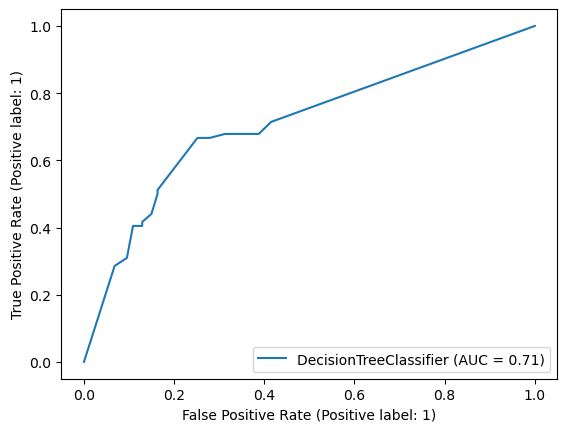

In [28]:
## ¿Cómo vemos esto graficamente?
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(dt, X_test, y_test) 
plt.show()

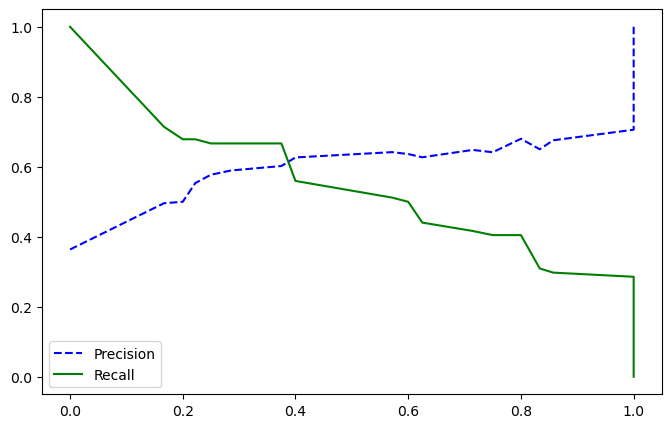

In [29]:
## precision y recall 

def plot_precision_recall_vs_threshold(precisions, 
recall, thresholds): 
    fig = plt.figure(figsize= (8,5))
    plt.plot(thresholds, precisions, "b--", 
    label="Precision")
    plt.plot(thresholds, recall, "g-", 
    label="Recall")
    plt.legend()
    
plot_precision_recall_vs_threshold(precision, 
recall, thresholds_2)
plt.show()    

In [30]:
## Eficiencia @k

scores = predictions_scores[:,1]
df_scores = pd.DataFrame({'scores': scores, 
'label_real': y_test})
df_scores.head()

,scores,label_real
200,0.200,0
40,1.000,0
630,0.000,1
356,0.400,1
305,0.375,0


In [31]:
top20 = df_scores.sort_values(by="scores", ascending=False).head(20)
top20.head()
top20.label_real.sum()
df_scores.label_real.sum()

84

### Medidas @k si k es 20 
* Etiquetas totales 79
* Eficiencia @20 $\frac{13}{20} = 0.65$
* Cobertura @20 $\frac{13}{79} = 0.16$

## Random Forest

Recuerda: ¿Qué es un random forest?
    
* Modelo de ensamble: varios arboles
* Cada arbol se crea con una muestra usando bagging y selecionando features de forma aleatoria 
* La prediccion es la media o la mayoria de todos los arboles 
* Buenos para decirnos cuales features son más importantes 

Algoritmo: base con N observaciones y M features
    
1. Crear k bootstrap samples de la base original de N. Normalmente k es alrededor de 100  
1. Para cada muestra, entrena un árbol de decisión usando m features ($m \leq M$) escogidas al azar de manera uniforme de M. 
1. Usa todos los arboles para predecir los resultados del test set. Usando la media (regresión) o la mayoría clasificación

![alternatvie text](imagenes/randomforest.png)

In [35]:
## Vamos a usar los mismos datos de diabetes que usamos para el árbol de decisión

diabetes = pd.read_csv('../data/diabetes.csv')
diabetes.rename(columns={col: col.lower() for col in diabetes.columns.values}, inplace=True)

# Dividimos en features y labels 
X = diabetes.drop(['outcome'], axis=1)
y = diabetes.outcome

# Dividimos en train y test
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size = 0.3, random_state = 1234)

In [36]:
#Declaramos el modelo
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train,y_train)

RandomForestClassifier()

Por default `RandomForestClassifier` de `sklearn` toma la siguiente:
* criterio de información: Gini 
* número de árboles: 100 
* features por árbol: $\sqrt{M}$ donde M es el número de features que tenemos

Puedes consultar como cambiar otros hiperparametros [acá](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [37]:
# ¿Qué variables escogio nuestro RF?

feature_imp = pd.Series(rfc.feature_importances_,index = X.columns).sort_values(ascending=False)
feature_imp

glucose                     0.251342
bmi                         0.159147
age                         0.143826
diabetespedigreefunction    0.123265
pregnancies                 0.086438
bloodpressure               0.085511
insulin                     0.082259
skinthickness               0.068212
dtype: float64

Si quieres saber como `sklearn` hizo esto lee este [post](https://towardsdatascience.com/the-mathematics-of-decision-trees-random-forest-and-feature-importance-in-scikit-learn-and-spark-f2861df67e3)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


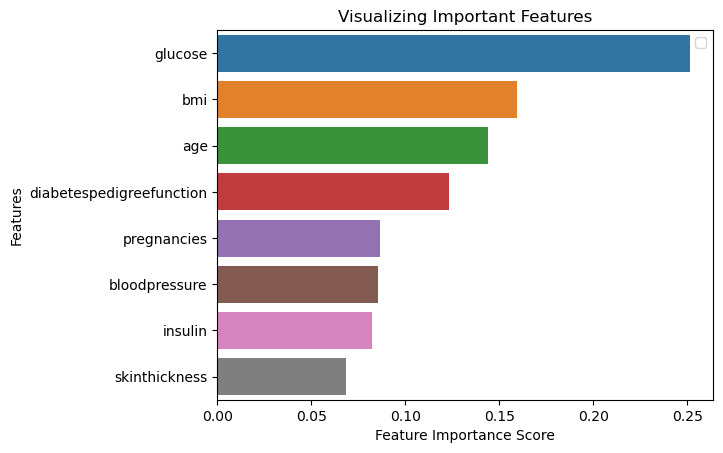

In [38]:
# Graficamente:
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Visualizing Important Features')
plt.legend()
plt.show()

In [39]:
# ¿Cómo lo hizo el RF?

predictions_labels = rfc.predict(X_test)
predictions_scores = rfc.predict_proba(X_test)
accuracy_score(y_test, predictions_labels)

0.7662337662337663

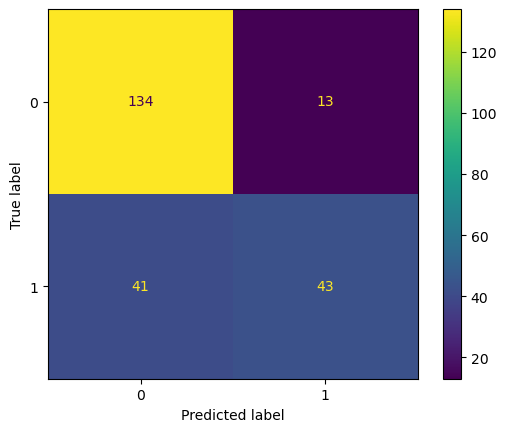

In [40]:
cm = confusion_matrix(y_test, predictions_labels, labels = rfc.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc.classes_)
disp.plot()
plt.show()

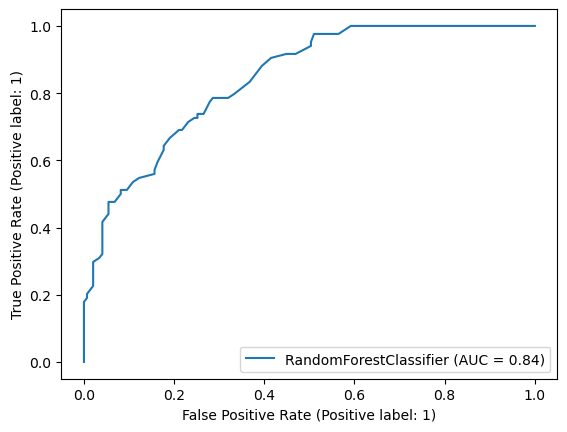

In [41]:
RocCurveDisplay.from_estimator(rfc, X_test, y_test) 
plt.show()

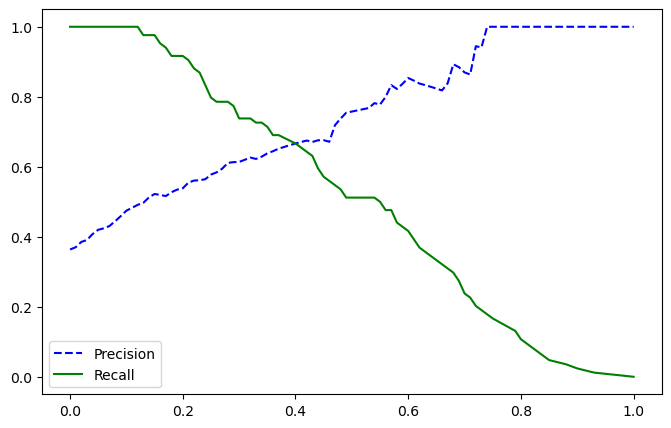

In [42]:
precision, recall, thresholds_2 = precision_recall_curve(y_test, predictions_scores[:,1])
thresholds_2 = np.append(thresholds_2, 1)
plot_precision_recall_vs_threshold(precision, 
recall, thresholds_2)
plt.show()  